# 심화 미션: 냉동 창고 온도 기록
- 상황: 양품·불량을 찍어주는 사람이 없다. 폐기 기록만 한참 뒤에 붙는다
- 목표: 다섯 날 배운 것을 한 데이터로 전부 돌려본다

### 용어 풀이 - 냉동 창고에서 쓰는 말

| 말 | 뜻 |
|---|---|
| 콜드체인 | 얼거나 차가운 상태를 끊지 않고 이어가는 물류. 한 번 녹으면 되돌릴 수 없다 |
| 제상 | 증발기에 낀 성에를 녹여 떼는 일. 주기적으로 돌리는데 그동안은 온도가 조금 오른다 |
| 복귀 온도 | 창고를 한 바퀴 돌고 설비로 돌아오는 공기의 온도. 내부 온도보다 조금 높다 |
| 압축기 | 냉기를 만드는 설비. 더 식혀야 하면 더 빨리 돈다 |
| 폐기 | 상해서 버린 것. 이 데이터에서 맞혀야 할 정답 |

### 오늘 쓰는 방법의 정식 이름

| 수업에서 쓰는 말 | 정식 이름 |
|---|---|
| 고립시키기 | 아이솔레이션 포레스트 (Isolation Forest) |
| 이웃과 비교하기 | 국소 이상치 인자 (Local Outlier Factor, LOF) |
| 이상 비율 | contamination |
| 이웃 수 | n_neighbors |
| 겹침 | 교집합 (intersection) |
| 지목 중 진짜 | 정밀도 (precision) |
| 전체 폐기 중 잡은 것 | 재현율 (recall) |
| 관리 한계선 | 관리상한 UCL / 관리하한 LCL |
| 관리도로 공정을 지켜보는 일 | 통계적 공정관리 (SPC) |

## Q1. 파일 열고 크기 확인하기

In [1]:
import pandas as pd

# ① 파일을 불러오는 것
df = pd.read_csv("../../data/day05_coldchain.csv")

# ② 행 수와 열 수가 한 덩어리로 담긴 것
print("행", df.shape[0], "/ 열", df.shape[1])

# ③ 참인 자리의 개수를 세는 것
폐기수 = (df["disposal"] == "폐기").sum()
print(f"폐기 {폐기수}건 ({폐기수 / len(df) * 100:.1f}%)")

행 3412 / 열 12
폐기 120건 (3.5%)


Q2. 시간 순으로 줄 세우기

In [2]:
# ① 글자로 된 시각을 날짜로 바꾸는 것
# ② 표기가 섞여 있어도 읽으라는 뜻
df["recorded_at"] = pd.to_datetime(df["recorded_at"], format='mixed')

# ③ 오름차순으로 정렬돼 있는지 참·거짓으로 알려주는 것
print("파일이 시간 순인가:", df["recorded_at"].is_monotonic_increasing)

# ④ 그 열 기준으로 줄을 세우는 것
df = df.sort_values("recorded_at").reset_index(drop=True)
print("기간:", df["recorded_at"].min(), "~", df["recorded_at"].max())

파일이 시간 순인가: False
기간: 2026-06-01 00:49:00 ~ 2026-09-03 09:19:00


Q3. 입력 열 고르고 빈칸 채우기

In [3]:
# ① 자료형으로 열을 골라주는 것
숫자열 = df.select_dtypes(include="number").columns.tolist()
print("숫자 열", len(숫자열), "개")

# ② 빈칸이면 참이 되는 것
빈칸 = df[숫자열].isna().sum()
print("빈칸이 있는 열:", 빈칸[빈칸 > 0].to_dict())

# ③ 빈칸을 채우는 것   ④ 가운데 값
X = df[숫자열].fillna(df[숫자열].median())
y = (df["disposal"] == "폐기").astype(int)

숫자 열 7 개
빈칸이 있는 열: {'humidity_pct': 42, 'power_kw': 27}


# 2부. 답을 보고 배우기 (Q4~Q9)

Q4. 학습용과 시험용으로 나누기

In [4]:
from sklearn.model_selection import train_test_split

# ① 나눠주는 도구
# ② 시험용으로 떼어둘 비율 (20%)
# ③ 드문 쪽 비율을 양쪽에 똑같이 맞추라는 뜻
학습입력, 시험입력, 학습정답, 시험정답 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"학습용 {len(학습입력)}건 (폐기 {학습정답.sum()}건)")
print(f"시험용 {len(시험입력)}건 (폐기 {시험정답.sum()}건)")

학습용 2729건 (폐기 96건)
시험용 683건 (폐기 24건)


## Q5. 아무것도 안 하는 기준 모델

In [5]:
# ① 시험용 정답이 정상인 자리만 참 - 정상을 무엇으로 적어뒀나
# ② 참인 비율. 참·거짓에 쓰면 비율이 나온다
기준정확도 = (시험정답 == 0).mean()
print(f"전부 정상이라 답하면 정확도: {기준정확도 * 100:.2f}%")
print("잡은 폐기: 0건")

전부 정상이라 답하면 정확도: 96.49%
잡은 폐기: 0건


## Q6. 손대지 않은 모델 한 번

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# ① 값을 같은 자로 바꿔주는 것
# ② 셋째 날에 쓴 그 분류 모델
모델 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

# ③ 배우게 하는 것 - 입력과 정답을 함께 준다
모델.fit(학습입력, 학습정답)

# ④ 답을 받는 것 - 정답은 주지 않는다
예측 = 모델.predict(시험입력)

# ⑤ 맞힌 비율
print(f"정확도: {(예측 == 시험정답).mean() * 100:.2f}%")

정확도: 97.80%


Q7. 네 칸으로 쪼개 보고 지표 구하기

In [7]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score

# ① 실제와 예측을 맞대어 네 칸으로 세는 것
맞게넘김, 헛경보, 놓친폐기, 잡은폐기 = confusion_matrix(시험정답, 예측).ravel()
print(f"잡은 폐기 {잡은폐기} / 놓친 폐기 {놓친폐기} / 헛경보 {헛경보}")

# ② 있는 것 중 몇 개 잡았나   ③ 짚은 것 중 몇 개 맞았나   ④ 둘을 함께 보는 값
print(f"재현율 {recall_score(시험정답, 예측):.3f}", end="  ")
print(f"정밀도 {precision_score(시험정답, 예측):.3f}", end="  ")
print(f"F1 {f1_score(시험정답, 예측):.3f}")

잡은 폐기 11 / 놓친 폐기 13 / 헛경보 2
재현율 0.458  정밀도 0.846  F1 0.595


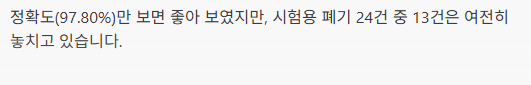

Q8. 드문 쪽을 무겁게 세고 다시

In [8]:
# Q6과 똑같이 표준화를 넣고, class_weight="balanced"만 추가한다
모델_가중치 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced"))
모델_가중치.fit(학습입력, 학습정답)
예측_가중치 = 모델_가중치.predict(시험입력)

맞게넘김_가중치, 헛경보_가중치, 놓친폐기_가중치, 잡은폐기_가중치 = confusion_matrix(시험정답, 예측_가중치).ravel()

print(f"정확도: {(예측_가중치 == 시험정답).mean() * 100:.2f}%")
print(f"잡은 폐기 {잡은폐기_가중치} / 놓친 폐기 {놓친폐기_가중치} / 헛경보 {헛경보_가중치}")
print(f"재현율 {recall_score(시험정답, 예측_가중치):.3f}", end="  ")
print(f"정밀도 {precision_score(시험정답, 예측_가중치):.3f}", end="  ")
print(f"F1 {f1_score(시험정답, 예측_가중치):.3f}")

정확도: 83.46%
잡은 폐기 20 / 놓친 폐기 4 / 헛경보 109
재현율 0.833  정밀도 0.155  F1 0.261


[Q8 결과]<br>
정확도 : [83.46]%<br>
잡은 폐기 [20]건 / 놓친 폐기 [4]건 / 헛경보 [109]건<br>
재현율 [0.833] / 정밀도 [0.155] / F1 [0.261]<br>
→ Q6(정확도 97.80%, 재현율 0.458)과 비교하면 정확도는 크게 떨어졌지만, 놓친 폐기가 13건 → 4건으로 줄고 재현율이 0.458 → 0.833으로 크게 올랐다. 대신 헛경보가 2건 → 109건으로 늘어 정밀도는 0.846 → 0.155로 떨어졌다.

Q9. 전후 비교표 적기

## Q9. 전후 비교

| 무엇 | 정확도 | 잡은 폐기 | 놓친 폐기 | 헛경보 | 재현율 |
|---|---|---|---|---|---|
| 아무것도 안 함 | [96.49%] | [0] | [24] | [0] | [0.000] |
| 손 안 댄 모델 | [97.80%] | [11] | [13] | [2] | [0.458] |
| 가중치 준 모델 | [83.46%] | [20] | [4] | [109] | [0.833] |

- 서 팀장에게 맞는 것은 : [가중치 준 모델. 버리기 전에 알고 싶다고 했으니 놓친 것을 줄이는 쪽]
- 무엇을 내줬나 : [헛경보가 2건에서 109건으로. 정확도도 14%p 내려갔다]

# 3부. 답 없이 찾기 (Q10~Q13)

Q10. 답을 가리고 이상한 것 지목하기

In [9]:
from sklearn.ensemble import IsolationForest

# ① 고립시켜 이상을 찾는 도구
# ② 전체의 몇 %를 이상으로 볼지 내가 정하는 자리
# ③ 다시 돌려도 같게 나오도록 고정하는 번호
탐지기 = IsolationForest(contamination=0.05, random_state=42)

# ④ 정답은 넣지 않는다
고립지목 = 탐지기.fit_predict(X)
고립이상 = (고립지목 == -1)
print("고립시키기 지목:", 고립이상.sum(), "건")

고립시키기 지목: 171 건


Q11. 답을 꺼내 채점하기

In [10]:
# ① 두 표시가 둘 다 참인 자리만   ② 참인 자리의 개수
잡은것 = (고립이상 & (y == 1)).sum()
print(f"지목 {고립이상.sum()}건 / 그중 폐기 {잡은것}건")
print(f"지목 중 진짜: {잡은것 / 고립이상.sum() * 100:.1f} %")
print(f"전체 폐기 중 잡은 것: {잡은것 / (y == 1).sum() * 100:.1f} %")
print(f"(견줄 값) 전체 폐기율: {(y == 1).mean() * 100:.1f} %")

지목 171건 / 그중 폐기 51건
지목 중 진짜: 29.8 %
전체 폐기 중 잡은 것: 42.5 %
(견줄 값) 전체 폐기율: 3.5 %


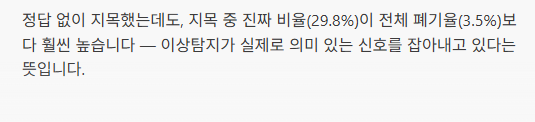

Q12. 다른 잣대로 한 번 더

In [11]:
from sklearn.neighbors import LocalOutlierFactor

# ① 이웃과 비교하는 도구
# ② 이웃을 몇 명까지 볼지
# ③ 앞과 같은 비율로 맞춘다 - 그래야 나란히 견줄 수 있다
이웃탐지기 = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
이웃이상 = (이웃탐지기.fit_predict(X) == -1)

# 잡은것(Q11에서 고립시키기용으로 쓴 이름)을 그대로 재사용하면 값이 덮어써지므로,
# 이웃 비교 결과는 이름을 따로 두어 구분한다
이웃잡은것 = (이웃이상 & (y == 1)).sum()
print(f"이웃 비교 {이웃이상.sum()}건 지목 / {이웃잡은것}건 폐기 / 지목 중 {이웃잡은것 / 이웃이상.sum() * 100:.1f}%")

이웃 비교 171건 지목 / 31건 폐기 / 지목 중 18.1%


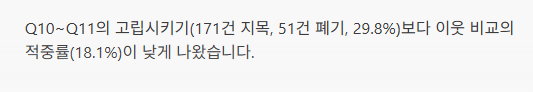

Q13. 둘이 같이 짚은 줄

In [12]:
# ① 둘 다 참인 자리만   ② 한쪽이라도 참이면
둘다 = 고립이상 & 이웃이상
둘중하나 = 고립이상 | 이웃이상

for 이름, m in [("둘 다 지목", 둘다), ("둘 중 하나라도", 둘중하나)]:
    h = (m & (y == 1)).sum()
    print(f"{이름} {m.sum()}건 / 폐기 {h}건 / 지목 중 {h / m.sum() * 100:.1f}%")

둘 다 지목 55건 / 폐기 26건 / 지목 중 47.3%
둘 중 하나라도 287건 / 폐기 56건 / 지목 중 19.5%


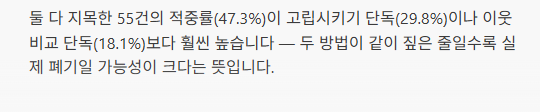

# 4부. 시간으로 보기와 마감 (Q14~Q15)

## Q14. 관리선과 흐름 — 언제 어디서였나

In [13]:
# ① 값들이 평균에서 얼마나 벌어져 있는지 재는 것
# ② 위로 넘었거나 아래로 넘었거나
평균 = df["temp_main_C"].mean()
표준편차 = df["temp_main_C"].std()
상한, 하한 = 평균 + 3 * 표준편차, 평균 - 3 * 표준편차
이탈 = (df["temp_main_C"] > 상한) | (df["temp_main_C"] < 하한)
h = (이탈 & (y == 1)).sum()
print(f"관리선 이탈 {이탈.sum()}건 / 폐기 {h}건 / 지목 중 {h / 이탈.sum() * 100:.1f}%")

# ③ 창문을 미끄러뜨리며 묶는 것   ④ 몇 개씩 묶을지
df["이동평균"] = df["temp_main_C"].rolling(window=20).mean()
mm, ms = df["이동평균"].mean(), df["이동평균"].std()
넘음 = df["이동평균"] > mm + 2 * ms
구간 = (넘음 != 넘음.shift()).cumsum()[넘음]
print(f"넘은 구간 {구간.nunique()}개 / 넘은 줄 {넘음.sum()}건")

# ⑤ 그 열 기준으로 묶어주는 것
큰구간 = df[넘음].groupby(구간).filter(lambda g: len(g) > 50)
for 창고, g in 큰구간.groupby("warehouse"):
    b = (g["disposal"] == "폐기").sum()
    print(f"  {창고}: {len(g)}건 중 폐기 {b}건 ({b / len(g) * 100:.1f}%)")

관리선 이탈 40건 / 폐기 36건 / 지목 중 90.0%
넘은 구간 7개 / 넘은 줄 139건
  A: 37건 중 폐기 1건 (2.7%)
  B: 28건 중 폐기 24건 (85.7%)
  C: 29건 중 폐기 1건 (3.4%)


Q15. 조기 경보 목록으로 마감하기

In [14]:
# ① 둘 중 하나라도 걸리면 목록에 넣는다
경보 = 둘다 | 이탈
h = (경보 & (y == 1)).sum()
print(f"조기 경보 {경보.sum()}건 / 폐기 {h}건 / 지목 중 {h / 경보.sum() * 100:.1f}%")
print(f"못 잡은 폐기: {(y == 1).sum() - h}건")

조기 경보 75건 / 폐기 42건 / 지목 중 56.0%
못 잡은 폐기: 78건


## Q15. 서 팀장님께

- 폐기 기록이 있는 창고라면 : [가중치 준 모델. 재현율 0.833으로 24건 중 20건을 잡는다]
- 폐기 기록이 없는 새 창고라면 : [조기 경보 75건. 열 건 열면 대여섯 건이 진짜다]
- 놓친 것 : [조기 경보로 못 잡은 폐기가 78건 있다]
- 언제 어디서였나 : [넘은 구간이 일곱 군데, 그중 큰 구간의 폐기가 B창고에 몰렸다]

- 오늘 한 일 : [                                                        ]
- 오늘 알게 된 것 : [                                                   ]
- 아직 막히는 것 : [                                                    ]